In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE

from scipy.stats import zscore

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE

from scipy.stats import zscore

In [3]:
df = pd.read_csv("employee_attrition_dataset.csv")

df.head()

,EmployeeID,Age,Gender,MaritalStatus,EducationLevel,EducationField,Department,JobRole,JobLevel,TotalWorkingYears,...,WorkLifeBalance,EmployeeEngagementScore,ManagerRating,TeamSize,ProjectsHandled,AverageMonthlyHours,PerformanceTrend3Months,PerformanceTrend6Months,SalaryGrowthLast3Years,Attrition
0,1,56,Male,Single,High School,IT,IT,Executive,4,1,...,1,23,5.0,23,16,259,0.740636,0.719257,15,0
1,2,46,Female,Single,Bachelor,Finance,HR,Analyst,2,9,...,4,53,3.0,8,15,133,1.857500,-0.198729,5,1
2,3,32,Male,Married,Master,HR,Finance,Engineer,3,30,...,5,26,4.0,4,18,146,-0.467347,0.713427,21,0
3,4,25,Male,Single,Bachelor,IT,IT,Engineer,5,7,...,5,42,2.0,24,4,243,-0.112854,1.251271,53,0
4,5,38,Female,Single,Master,HR,Sales,Manager,3,38,...,5,93,3.0,15,13,313,-1.429788,-0.644314,14,0


In [4]:
df.shape

(10100, 37)

In [5]:
df.isnull().sum()

EmployeeID                    0
Age                           0
Gender                        0
MaritalStatus                 0
EducationLevel                0
EducationField                0
Department                    0
JobRole                       0
JobLevel                      0
TotalWorkingYears             0
YearsAtCompany                0
YearsInCurrentRole            0
YearsSinceLastPromotion       0
YearsWithCurrManager          0
MonthlyIncome               506
PercentSalaryHike             0
BonusPercent                  0
StockOptionLevel              0
PerformanceRating             0
TrainingTimesLastYear         0
CertificationCount            0
AbsenceDays                   0
LateMarks                     0
OvertimeHours                 0
JobSatisfaction             508
EnvironmentSatisfaction       0
RelationshipSatisfaction      0
WorkLifeBalance               0
EmployeeEngagementScore       0
ManagerRating               503
TeamSize                      0
Projects

In [6]:
missing_percent = (
    df.isnull().sum()/len(df)
)*100

missing_percent.sort_values(
    ascending=False
)

JobSatisfaction             5.029703
MonthlyIncome               5.009901
ManagerRating               4.980198
Age                         0.000000
EmployeeID                  0.000000
EducationLevel              0.000000
MaritalStatus               0.000000
Gender                      0.000000
EducationField              0.000000
TotalWorkingYears           0.000000
YearsAtCompany              0.000000
JobRole                     0.000000
Department                  0.000000
YearsSinceLastPromotion     0.000000
YearsWithCurrManager        0.000000
PercentSalaryHike           0.000000
BonusPercent                0.000000
StockOptionLevel            0.000000
PerformanceRating           0.000000
YearsInCurrentRole          0.000000
JobLevel                    0.000000
CertificationCount          0.000000
TrainingTimesLastYear       0.000000
LateMarks                   0.000000
AbsenceDays                 0.000000
EnvironmentSatisfaction     0.000000
RelationshipSatisfaction    0.000000
W

In [7]:
num_cols = df.select_dtypes(
    exclude='object'
).columns

imputer_num = SimpleImputer(
    strategy='median'
)

df[num_cols] = imputer_num.fit_transform(
    df[num_cols]
)

In [8]:
cat_cols = df.select_dtypes(
    include='object'
).columns

imputer_cat = SimpleImputer(
    strategy='most_frequent'
)

df[cat_cols] = imputer_cat.fit_transform(
    df[cat_cols]
)

In [9]:
cat_cols = df.select_dtypes(
    include='object'
).columns

imputer_cat = SimpleImputer(
    strategy='most_frequent'
)

df[cat_cols] = imputer_cat.fit_transform(
    df[cat_cols]
)

In [10]:
df.shape

(10100, 37)

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(10000, 37)

In [13]:
df['MonthlyIncome'].describe()

count     10000.00000
mean     113822.57060
std       68423.36586
min       20042.00000
25%       68176.50000
50%      110515.00000
75%      153792.00000
max      993085.00000
Name: MonthlyIncome, dtype: float64

In [14]:
Q1 = df['MonthlyIncome'].quantile(.25)
Q3 = df['MonthlyIncome'].quantile(.75)

IQR = Q3-Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

lower,upper

(np.float64(-60246.75), np.float64(282215.25))

In [15]:
df['MonthlyIncome'] = np.where(
    df['MonthlyIncome']>upper,
    upper,
    df['MonthlyIncome']
)

df['MonthlyIncome'] = np.where(
    df['MonthlyIncome']<lower,
    lower,
    df['MonthlyIncome']
)

In [16]:
df['MonthlyIncome'].describe()

count     10000.000000
mean     111419.739800
std       52423.056725
min       20042.000000
25%       68176.500000
50%      110515.000000
75%      153792.000000
max      282215.250000
Name: MonthlyIncome, dtype: float64

In [17]:
df['IncomePerYearExperience'] = (
    df['MonthlyIncome']
    /
    (df['TotalWorkingYears']+1)
)

In [18]:
df['PromotionGapRatio'] = (
    df['YearsSinceLastPromotion']
    /
    (df['YearsAtCompany']+1)
)

In [19]:
df['StressIndex'] = (
    df['OvertimeHours']
    *
    df['AbsenceDays']
)

In [20]:
df['OverallSatisfaction'] = (
    df['JobSatisfaction']
    +
    df['EnvironmentSatisfaction']
    +
    df['RelationshipSatisfaction']
    +
    df['WorkLifeBalance']
)/4

In [21]:
df['CareerGrowthScore'] = (
    df['TrainingTimesLastYear']
    +
    df['CertificationCount']
    +
    df['PercentSalaryHike']
)

In [22]:
df['EmployeeRiskScore'] = (
      (6-df['JobSatisfaction'])
    + (6-df['WorkLifeBalance'])
    + (df['AbsenceDays']/10)
    + (df['OvertimeHours']/20)
)

In [23]:
df.head()

,EmployeeID,Age,Gender,MaritalStatus,EducationLevel,EducationField,Department,JobRole,JobLevel,TotalWorkingYears,...,PerformanceTrend3Months,PerformanceTrend6Months,SalaryGrowthLast3Years,Attrition,IncomePerYearExperience,PromotionGapRatio,StressIndex,OverallSatisfaction,CareerGrowthScore,EmployeeRiskScore
0,1.0,56.0,Male,Single,High School,IT,IT,Executive,4.0,1.0,...,0.740636,0.719257,15.0,0.0,59940.500000,0.000000,1000.0,2.0,24.0,12.50
1,2.0,46.0,Female,Single,Bachelor,Finance,HR,Analyst,2.0,9.0,...,1.857500,-0.198729,5.0,1.0,13622.200000,2.000000,150.0,3.0,22.0,7.80
2,3.0,32.0,Male,Married,Master,HR,Finance,Engineer,3.0,30.0,...,-0.467347,0.713427,21.0,0.0,3565.000000,3.500000,106.0,3.5,23.0,7.85
3,4.0,25.0,Male,Single,Bachelor,IT,IT,Engineer,5.0,7.0,...,-0.112854,1.251271,53.0,0.0,16794.750000,0.777778,1647.0,3.5,43.0,11.75
4,5.0,38.0,Female,Single,Master,HR,Sales,Manager,3.0,38.0,...,-1.429788,-0.644314,14.0,0.0,4637.102564,8.000000,738.0,2.5,30.0,11.00


In [24]:
cat_cols = df.select_dtypes(
    include='object'
).columns

cat_cols

Index(['Gender', 'MaritalStatus', 'EducationLevel', 'EducationField',
       'Department', 'JobRole'],
      dtype='object')

In [25]:
label_encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col]
    )

    label_encoders[col] = le

In [26]:
label_encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col]
    )

    label_encoders[col] = le

In [27]:
df.head()

,EmployeeID,Age,Gender,MaritalStatus,EducationLevel,EducationField,Department,JobRole,JobLevel,TotalWorkingYears,...,PerformanceTrend3Months,PerformanceTrend6Months,SalaryGrowthLast3Years,Attrition,IncomePerYearExperience,PromotionGapRatio,StressIndex,OverallSatisfaction,CareerGrowthScore,EmployeeRiskScore
0,1.0,56.0,1,2,1,4,2,3,4.0,1.0,...,0.740636,0.719257,15.0,0.0,59940.500000,0.000000,1000.0,2.0,24.0,12.50
1,2.0,46.0,0,2,0,2,1,0,2.0,9.0,...,1.857500,-0.198729,5.0,1.0,13622.200000,2.000000,150.0,3.0,22.0,7.80
2,3.0,32.0,1,1,2,3,0,2,3.0,30.0,...,-0.467347,0.713427,21.0,0.0,3565.000000,3.500000,106.0,3.5,23.0,7.85
3,4.0,25.0,1,2,0,4,2,2,5.0,7.0,...,-0.112854,1.251271,53.0,0.0,16794.750000,0.777778,1647.0,3.5,43.0,11.75
4,5.0,38.0,0,2,2,3,4,4,3.0,38.0,...,-1.429788,-0.644314,14.0,0.0,4637.102564,8.000000,738.0,2.5,30.0,11.00


In [28]:
X = df.drop(
    columns=['Attrition']
)

y = df['Attrition']

In [29]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print(X_train.shape)
print(X_test.shape)

(8000, 42)
(2000, 42)


In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [32]:
X_train_scaled

array([[ 0.4671067 ,  0.11331417, -0.99675526, ..., -0.35453368,
         0.15773449, -0.66618067],
       [-1.10681726, -0.6370418 ,  1.0032553 , ..., -1.40112758,
         0.93999001,  1.74059925],
       [ 0.34704411, -0.97053334,  1.0032553 , ...,  0.34319558,
        -0.23339327, -0.2003523 ],
       ...,
       [ 1.24371846, -0.47029603, -0.99675526, ..., -0.35453368,
         0.93999001,  1.6823707 ],
       [ 1.06465959, -0.6370418 , -0.99675526, ..., -1.74999221,
         0.54886225,  1.35240894],
       [-0.84185154,  0.69692437, -0.99675526, ..., -0.00566905,
         0.35329837, -0.2003523 ]], shape=(8000, 42))

In [33]:
X_train_scaled

array([[ 0.4671067 ,  0.11331417, -0.99675526, ..., -0.35453368,
         0.15773449, -0.66618067],
       [-1.10681726, -0.6370418 ,  1.0032553 , ..., -1.40112758,
         0.93999001,  1.74059925],
       [ 0.34704411, -0.97053334,  1.0032553 , ...,  0.34319558,
        -0.23339327, -0.2003523 ],
       ...,
       [ 1.24371846, -0.47029603, -0.99675526, ..., -0.35453368,
         0.93999001,  1.6823707 ],
       [ 1.06465959, -0.6370418 , -0.99675526, ..., -1.74999221,
         0.54886225,  1.35240894],
       [-0.84185154,  0.69692437, -0.99675526, ..., -0.00566905,
         0.35329837, -0.2003523 ]], shape=(8000, 42))

In [34]:
y_train.value_counts()

Attrition
0.0    6783
1.0    1217
Name: count, dtype: int64

In [35]:
smote = SMOTE(
    random_state=42
)

X_train_smote,y_train_smote = (
    smote.fit_resample(
        X_train_scaled,
        y_train
    )
)

In [36]:
pd.Series(
    y_train_smote
).value_counts()

Attrition
0.0    6783
1.0    6783
Name: count, dtype: int64

In [37]:
print(X_train_smote.shape)
print(X_test_scaled.shape)

(13566, 42)
(2000, 42)


In [38]:
df.to_csv(
    "employee_attrition_cleaned.csv",
    index=False
)

In [39]:
import pickle

with open(
    "label_encoders.pkl",
    "wb"
) as f:

    pickle.dump(
        label_encoders,
        f
    )

In [40]:
with open(
    "scaler.pkl",
    "wb"
) as f:

    pickle.dump(
        scaler,
        f
    )

In [41]:
# ----------------------------------ML

In [42]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import cross_val_score

# Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [43]:
models = {

    "Logistic Regression":
        LogisticRegression(),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            random_state=42
        ),

    "SVM":
        SVC(
            probability=True
        ),

    "KNN":
        KNeighborsClassifier(),

    "Naive Bayes":
        GaussianNB(),

    "AdaBoost":
        AdaBoostClassifier(
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            eval_metric='logloss',
            random_state=42
        ),

    "LightGBM":
        LGBMClassifier(
            random_state=42
        ),

    "CatBoost":
        CatBoostClassifier(
            verbose=0,
            random_state=42
        )
}

In [44]:
results = []

In [45]:
for name, model in models.items():

    print(f"Training {name}")

    model.fit(
        X_train_smote,
        y_train_smote
    )

    y_pred = model.predict(
        X_test_scaled
    )

    if hasattr(model,"predict_proba"):

        y_prob = model.predict_proba(
            X_test_scaled
        )[:,1]

    else:

        y_prob = y_pred

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append([

        name,
        accuracy,
        precision,
        recall,
        f1,
        auc

    ])

Training Logistic Regression
Training Decision Tree
Training Random Forest
Training SVM
Training KNN
Training Naive Bayes
Training AdaBoost
Training XGBoost
Training LightGBM
[LightGBM] [Info] Number of positive: 6783, number of negative: 6783
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004767 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10694
[LightGBM] [Info] Number of data points in the train set: 13566, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


C:\Users\azad singh s\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\azad singh s\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training CatBoost


C:\Users\azad singh s\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [46]:
results_df = pd.DataFrame(

    results,

    columns=[

        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC_AUC'
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.5285,0.153846,0.467105,0.231459,0.503090
1,Decision Tree,0.7295,0.171745,0.203947,0.186466,0.513825
2,Random Forest,0.8475,0.000000,0.000000,0.000000,0.496829
3,SVM,0.7695,0.157205,0.118421,0.135084,0.520840
4,KNN,0.3560,0.153521,0.717105,0.252900,0.521069
5,Naive Bayes,0.6405,0.153589,0.302632,0.203765,0.517340
6,AdaBoost,0.7180,0.134831,0.157895,0.145455,0.511585
7,XGBoost,0.8380,0.083333,0.006579,0.012195,0.511971
8,LightGBM,0.8470,0.000000,0.000000,0.000000,0.488910
9,CatBoost,0.8480,0.000000,0.000000,0.000000,0.506746


In [47]:
results_df.sort_values(
    by='ROC_AUC',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
4,KNN,0.3560,0.153521,0.717105,0.252900,0.521069
3,SVM,0.7695,0.157205,0.118421,0.135084,0.520840
5,Naive Bayes,0.6405,0.153589,0.302632,0.203765,0.517340
1,Decision Tree,0.7295,0.171745,0.203947,0.186466,0.513825
7,XGBoost,0.8380,0.083333,0.006579,0.012195,0.511971
6,AdaBoost,0.7180,0.134831,0.157895,0.145455,0.511585
9,CatBoost,0.8480,0.000000,0.000000,0.000000,0.506746
0,Logistic Regression,0.5285,0.153846,0.467105,0.231459,0.503090
2,Random Forest,0.8475,0.000000,0.000000,0.000000,0.496829
8,LightGBM,0.8470,0.000000,0.000000,0.000000,0.488910


In [48]:
results_df.sort_values(
    by='F1',
    ascending=False
)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
4,KNN,0.3560,0.153521,0.717105,0.252900,0.521069
0,Logistic Regression,0.5285,0.153846,0.467105,0.231459,0.503090
5,Naive Bayes,0.6405,0.153589,0.302632,0.203765,0.517340
1,Decision Tree,0.7295,0.171745,0.203947,0.186466,0.513825
6,AdaBoost,0.7180,0.134831,0.157895,0.145455,0.511585
3,SVM,0.7695,0.157205,0.118421,0.135084,0.520840
7,XGBoost,0.8380,0.083333,0.006579,0.012195,0.511971
2,Random Forest,0.8475,0.000000,0.000000,0.000000,0.496829
8,LightGBM,0.8470,0.000000,0.000000,0.000000,0.488910
9,CatBoost,0.8480,0.000000,0.000000,0.000000,0.506746


In [49]:
best_model_name = results_df.sort_values(
    by='ROC_AUC',
    ascending=False
).iloc[0]['Model']

print(best_model_name)

KNN


In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(
        model,
        X_test,
        y_test):

    pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        pred
    )

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d'
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

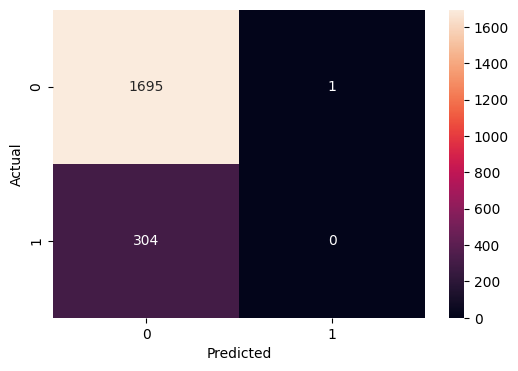

In [51]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train_smote,
    y_train_smote
)

plot_confusion_matrix(
    rf,
    X_test_scaled,
    y_test
)

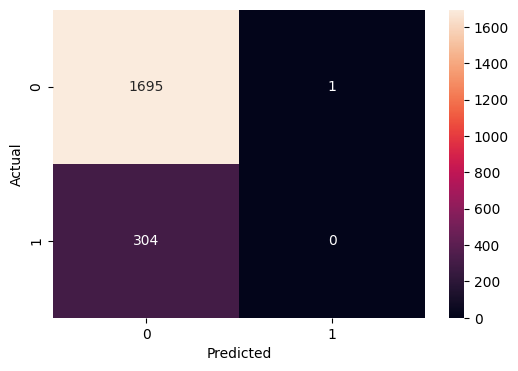

In [52]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train_smote,
    y_train_smote
)

plot_confusion_matrix(
    rf,
    X_test_scaled,
    y_test
)

In [53]:
pred = rf.predict(
    X_test_scaled
)

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

         0.0       0.85      1.00      0.92      1696
         1.0       0.00      0.00      0.00       304

    accuracy                           0.85      2000
   macro avg       0.42      0.50      0.46      2000
weighted avg       0.72      0.85      0.78      2000



In [54]:
lr = LogisticRegression()

scores = cross_val_score(

    lr,

    X_train_smote,
    y_train_smote,

    cv=5,

    scoring='f1'
)

print(scores)
print(scores.mean())

[0.53671072 0.54337394 0.52965311 0.55711712 0.54756718]
0.5428844129795325


In [55]:
rf = RandomForestClassifier(
    random_state=42
)

scores = cross_val_score(

    rf,

    X_train_smote,
    y_train_smote,

    cv=5,

    scoring='f1'
)

print(scores.mean())

0.8557248309967367


In [56]:
xgb = XGBClassifier(
    eval_metric='logloss'
)

scores = cross_val_score(
    xgb,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print(scores.mean())

0.8289533717622358


In [57]:
xgb = XGBClassifier(
    eval_metric='logloss'
)

scores = cross_val_score(
    xgb,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print(scores.mean())

0.8289533717622358


In [58]:
rf.fit(
    X_train_smote,
    y_train_smote
)

train_pred = rf.predict(
    X_train_smote
)

train_acc = accuracy_score(
    y_train_smote,
    train_pred
)

print(train_acc)

1.0


In [59]:
rf.fit(
    X_train_smote,
    y_train_smote
)

train_pred = rf.predict(
    X_train_smote
)

train_acc = accuracy_score(
    y_train_smote,
    train_pred
)

print(train_acc)

1.0


In [60]:
print("Train:",train_acc)
print("Test :",test_acc)

Train: 1.0


NameError: name 'test_acc' is not defined

In [ ]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
        rf.feature_importances_

})

In [ ]:
importance.sort_values(
    by='Importance',
    ascending=False
).head(20)

In [ ]:
top20 = importance.sort_values(
    by='Importance',
    ascending=False
).head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top20
)

plt.show()

In [ ]:
from sklearn.metrics import roc_curve

probs = rf.predict_proba(
    X_test_scaled
)[:,1]

fpr,tpr,thresholds = roc_curve(
    y_test,
    probs
)

plt.plot(
    fpr,
    tpr
)

plt.plot(
    [0,1],
    [0,1]
)

plt.xlabel("FPR")
plt.ylabel("TPR")

plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = (
    precision_recall_curve(
        y_test,
        probs
    )
)

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

In [ ]:
# --------------------------------------------------------Hyperparameter Tuning + Threshold Optimization + Production Model Selection

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
rf_params = {

    'n_estimators':[100,200,300],

    'max_depth':[5,10,20,None],

    'min_samples_split':[2,5,10],

    'min_samples_leaf':[1,2,4]
}

In [ ]:
rf = RandomForestClassifier(
    random_state=42
)

In [ ]:
grid = GridSearchCV(

    estimator=rf,

    param_grid=rf_params,

    cv=5,

    scoring='f1',

    n_jobs=-1,

    verbose=1
)

grid.fit(
    X_train_smote,
    y_train_smote
)

In [ ]:
grid.best_params_

In [ ]:
grid.best_score_

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_dist = {

'n_estimators':
    [100,200,300,500],

'max_depth':
    [5,10,20,30,None],

'min_samples_split':
    [2,5,10,20],

'min_samples_leaf':
    [1,2,4,8],

'max_features':
    ['sqrt','log2']
}

In [ ]:
random_search = RandomizedSearchCV(

    estimator=rf,

    param_distributions=param_dist,

    n_iter=50,

    cv=5,

    scoring='f1',

    random_state=42,

    n_jobs=-1
)

random_search.fit(
    X_train_smote,
    y_train_smote
)

In [ ]:
random_search.best_score_

In [ ]:
xgb = XGBClassifier(
    eval_metric='logloss'
)

In [ ]:
xgb_params = {

'n_estimators':
    [100,200,300],

'learning_rate':
    [0.01,0.05,0.1],

'max_depth':
    [3,5,7],

'subsample':
    [0.7,0.8,1],

'colsample_bytree':
    [0.7,0.8,1]
}

In [ ]:
xgb_grid.best_params_

In [ ]:
lgbm = LGBMClassifier()

In [ ]:
params = {

'n_estimators':
    [100,200,500],

'learning_rate':
    [0.01,0.05,0.1],

'num_leaves':
    [31,50,100],

'max_depth':
    [-1,5,10]
}

In [ ]:
grid = GridSearchCV(

    lgbm,

    params,

    cv=5,

    scoring='f1',

    n_jobs=-1
)

grid.fit(
    X_train_smote,
    y_train_smote
)

In [ ]:
grid.best_params_

In [ ]:
cat = CatBoostClassifier(
    verbose=0
)

In [ ]:
params = {

'depth':[4,6,8],

'learning_rate':
    [0.01,0.05,0.1],

'iterations':
    [100,200,500]
}

In [ ]:
grid = GridSearchCV(

    cat,

    params,

    cv=5,

    scoring='f1',

    n_jobs=-1
)

grid.fit(
    X_train_smote,
    y_train_smote
)

In [ ]:
pip install optuna

In [ ]:
import optuna

In [ ]:
def objective(trial):

    params = {

        'n_estimators':
            trial.suggest_int(
                'n_estimators',
                100,
                500
            ),

        'max_depth':
            trial.suggest_int(
                'max_depth',
                3,
                20
            ),

        'min_samples_split':
            trial.suggest_int(
                'min_samples_split',
                2,
                20
            )
    }

    model = RandomForestClassifier(
        **params
    )

    score = cross_val_score(

        model,

        X_train_smote,

        y_train_smote,

        cv=3,

        scoring='f1'

    ).mean()

    return score

In [ ]:
study = optuna.create_study(
    direction='maximize'
)

study.optimize(
    objective,
    n_trials=50
)

In [ ]:
study.best_value

In [ ]:
best_model = XGBClassifier(
    **xgb_grid.best_params_
)

best_model.fit(
    X_train_smote,
    y_train_smote
)

In [ ]:
probs = best_model.predict_proba(
    X_test_scaled
)[:,1]

In [ ]:
thresholds = np.arange(
    0.1,
    0.9,
    0.05
)

In [ ]:
results = []

for t in thresholds:

    preds = (
        probs >= t
    ).astype(int)

    f1 = f1_score(
        y_test,
        preds
    )

    results.append([t,f1])

In [ ]:
threshold_df.sort_values(
    by='F1',
    ascending=False
).head()

In [ ]:
best_threshold = (
    threshold_df.sort_values(
        by='F1',
        ascending=False
    )
    .iloc[0]['Threshold']
)

best_threshold

In [ ]:
# ----------------------------------------SHAP Explainability + Feature Importance + PKL Saving + Tableau Integration + Deployment Architecture

In [ ]:
pip install shap

In [ ]:
import shap
import matplotlib.pyplot as plt

In [ ]:
best_model = XGBClassifier(
    **xgb_grid.best_params_
)

best_model.fit(
    X_train_smote,
    y_train_smote
)

In [ ]:
explainer = shap.TreeExplainer(
    best_model
)

In [ ]:
shap_values = explainer.shap_values(
    X_test_scaled
)

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns
)

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns,
    plot_type='bar'
)

In [ ]:
employee_index = 5

In [ ]:
shap.force_plot(
    explainer.expected_value,
    shap_values[employee_index],
    X_test_scaled[employee_index]
)

In [ ]:
importance = pd.DataFrame({

'Feature':
    X.columns,

'Importance':
    best_model.feature_importances_

})

In [ ]:
importance.sort_values(
    by='Importance',
    ascending=False
)

In [ ]:
import seaborn as sns

top20 = importance.sort_values(
    by='Importance',
    ascending=False
).head(20)

plt.figure(figsize=(12,8))

sns.barplot(

    x='Importance',

    y='Feature',

    data=top20

)

plt.show()

In [ ]:
import pickle

In [ ]:
with open(
    "employee_attrition_model.pkl",
    "wb"
) as f:

    pickle.dump(
        best_model,
        f
    )

In [ ]:
with open(
    "employee_attrition_model.pkl",
    "rb"
) as f:

    loaded_model = pickle.load(
        f
    )

In [ ]:
sample_pred = loaded_model.predict(
    X_test_scaled[:5]
)

sample_pred

In [ ]:
from imblearn.pipeline import Pipeline

In [ ]:
pipeline = Pipeline([

('scaler',StandardScaler()),

('model',best_model)

])

In [ ]:
pipeline.fit(
    X_train,
    y_train
)

In [ ]:
with open(
    "attrition_pipeline.pkl",
    "wb"
) as f:

    pickle.dump(
        pipeline,
        f
    )